# Sismicidad en Costa Rica: patrones espaciales y temporales (2015-2025)

**Autor:** Bryan Ramírez Coria

**Curso:** Programación para SIG

## Introducción

Costa Rica se ubica sobre uno de los límites de placas tectónicas más
activos del planeta: la placa de Cocos subduce bajo la placa Caribe a lo
largo de la costa Pacífica, lo que provoca que el país registre miles de
sismos cada año (U.S. Geological Survey [USGS], 2009). La gran mayoría de esos eventos son de baja magnitud y pasan
inadvertidos para la población, pero el registro acumulado permite estudiar cómo se
distribuye la sismicidad en el tiempo y según su magnitud y profundidad.

Este cuaderno procesa el catálogo sísmico de Costa Rica entre 2015 y 2025 para responder tres preguntas:

1. ¿Cómo ha variado la cantidad de sismos registrados en Costa Rica año con año entre 2015 y 2025?
2. ¿Cuál es la distribución de magnitudes de los sismos registrados, y qué tan frecuentes son los sismos de mayor magnitud en comparación con los de menor magnitud?
3. ¿Existe alguna relación entre la profundidad del foco sísmico y la magnitud del evento?

Los datos provienen del catálogo sísmico del *United States Geological Survey* (USGS, 2026),
consultado mediante su API pública FDSN Event Web Service, filtrado para el territorio
de Costa Rica (caja delimitadora aproximada: 8.0°N a 11.3°N, -86.5°O a -82.5°O) y magnitud mínima de 2.5.

> U.S. Geological Survey. (2026). *Earthquake Catalog* [Conjunto de datos].
USGS Earthquake Hazards Program. https://earthquake.usgs.gov/earthquakes/search/

Las variables principales del conjunto de datos son la fecha y
hora del evento (`time`), las coordenadas del epicentro (`latitude`, `longitude`), la
profundidad del foco sísmico en kilómetros (`depth`), la magnitud en la escala de
magnitud de momento (`mag`) y una descripción textual de la ubicación (`place`).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

pd.set_option("display.max_columns", 10)

AZUL = "#1F77B4"
NARANJA = "#D97B1B"
MORADO = "#8F00FF"

## Datos
Los datos se cargan directamente desde la URL de la API del USGS (USGS, 2026), lo que
permite visualizar los datos en este trabajo sin depender de un archivo local.

In [ ]:
url = ("https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv&starttime=2015-01-01&endtime=2025-12-31"
    "&minlatitude=8.0&maxlatitude=11.3"
    "&minlongitude=-86.5&maxlongitude=-82.5"
    "&minmagnitude=2.5")

sismos = pd.read_csv(url)
sismos.head()

,time,latitude,longitude,depth,mag,...,magError,magNst,status,locationSource,magSource
0,2025-12-20T12:43:51.342Z,8.7445,-83.5964,36.540,4.1,...,0.131,16.0,reviewed,us,us
1,2025-12-07T14:20:43.819Z,8.8276,-83.9370,10.000,4.4,...,0.131,17.0,reviewed,us,us
2,2025-11-25T02:48:57.992Z,8.8225,-84.0746,10.000,4.3,...,0.178,9.0,reviewed,us,us
3,2025-11-22T18:41:20.057Z,8.8416,-84.0883,10.998,5.1,...,0.044,50.0,reviewed,us,us
4,2025-11-22T10:29:01.638Z,11.0286,-85.1706,218.702,4.5,...,0.057,90.0,reviewed,us,us


In [ ]:
print("Dimensiones (filas, columnas):", sismos.shape)
sismos.dtypes

Dimensiones (filas, columnas): (533, 22)


,0
time,object
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
nst,float64
gap,float64
dmin,float64
rms,float64


El catálogo trae columnas que no se usan en este análisis (identificadores, tipo de magnitud, metadatos de la red que detectó el evento, entre otras).
Se conservan solo las columnas necesarias, se convierte la fecha a un tipo de dato temporal y se deriva el año de cada evento. Las filas sin magnitud o
sin profundidad se descartan, porque ambas variables son indispensables para las preguntas planteadas.


In [ ]:
sismos = sismos[["time", "latitude", "longitude", "depth", "mag", "place"]].copy()
sismos["time"] = pd.to_datetime(sismos["time"])
sismos["año"] = sismos["time"].dt.year
sismos = sismos.dropna(subset=["mag", "depth"])

print("DimensioneS:", sismos.shape)
sismos.head()

DimensioneS: (533, 7)


,time,latitude,longitude,depth,mag,place,año
0,2025-12-20 12:43:51.342000+00:00,8.7445,-83.5964,36.540,4.1,"25 km SSW of Puerto Cortés, Costa Rica",2025
1,2025-12-07 14:20:43.819000+00:00,8.8276,-83.9370,10.000,4.4,"47 km WSW of Puerto Cortés, Costa Rica",2025
2,2025-11-25 02:48:57.992000+00:00,8.8225,-84.0746,10.000,4.3,"62 km WSW of Puerto Cortés, Costa Rica",2025
3,2025-11-22 18:41:20.057000+00:00,8.8416,-84.0883,10.998,5.1,"63 km WSW of Puerto Cortés, Costa Rica",2025
4,2025-11-22 10:29:01.638000+00:00,11.0286,-85.1706,218.702,4.5,"9 km NNW of San José, Costa Rica",2025


## Sismos localizados por año
La tabla siguiente agrupa los sismos por
año y resume, para cada uno, la cantidad de eventos detectados y su magnitud promedio.

In [ ]:
resumen_anual = (
    sismos.groupby("año")
    .agg(cantidad_sismos=("mag", "count"), magnitud_promedio=("mag", "mean"))
    .reset_index()
)

resumen_anual.style.format({
    "cantidad_sismos": "{:,.0f}",
    "magnitud_promedio": "{:.2f}"
}).hide(axis="index")

año,cantidad_sismos,magnitud_promedio
2015,51,4.47
2016,46,4.46
2017,40,4.48
2018,72,4.43
2019,54,4.51
2020,45,4.56
2021,40,4.46
2022,47,4.36
2023,46,4.32
2024,53,4.58


La cantidad de sismos detectados por año se mantiene en el orden de
los cientos o miles, con cierta variación entre años, mientras que la magnitud
promedio se mueve dentro de un rango estrecho, lo cual sugiere que las diferencias
anuales responden más a la cantidad de eventos pequeños detectados que a cambios en la
intensidad típica de la sismicidad.

Con el siguiente gráfico se puede observar de una forma mas visual dicho análisis.

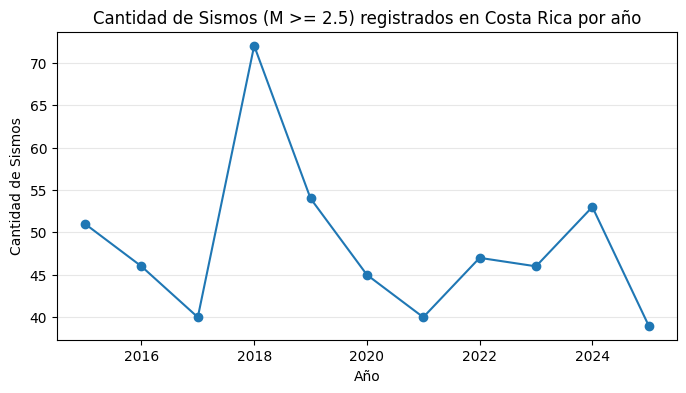

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

resumen_anual.plot(x="año", y="cantidad_sismos", kind="line", ax=ax, color=AZUL, marker="o", legend=False)

ax.set_title("Cantidad de Sismos (M >= 2.5) registrados en Costa Rica por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de Sismos")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)

plt.show()

El gráfico muestra cómo ha evolucionado la cantidad de sismos detectados año con año.
Los años con picos destacables suelen coincidir con enjambres sísmicos o con la ocurrencia
de un sismo principal seguido de numerosas réplicas, mientras que los años más bajos
reflejan periodos de menor actividad relativa o cambios en la cobertura de la red de detección.


## Distribución de las magnitudes

La mayoría de los sismos que ocurren en Costa Rica son de magnitud baja, y los eventos de magnitud alta son comparativamente escasos.
El siguiente histograma muestra esta distribución para el conjunto completo de sismos del período analizado.

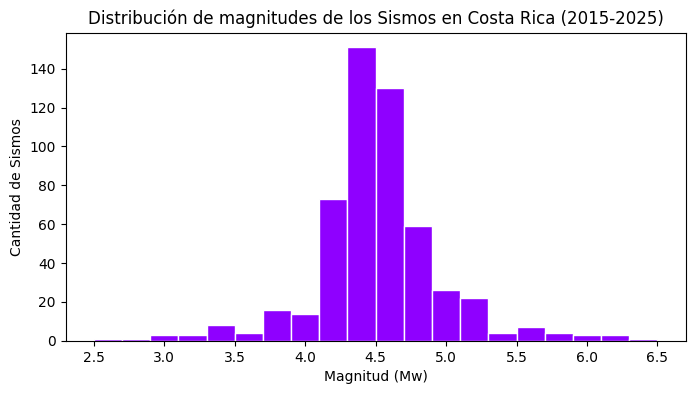

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sismos["mag"].plot(kind="hist", bins=20, ax=ax, color=MORADO, edgecolor="white")

ax.set_title("Distribución de magnitudes de los Sismos en Costa Rica (2015-2025)")
ax.set_xlabel("Magnitud (Mw)")
ax.set_ylabel("Cantidad de Sismos")

plt.show()

La distribución es asimétrica: la mayor parte de los sismos se concentra entre magnitud 2.5 y 3.5, y la cantidad de eventos decrece con rapidez a medida que aumenta la magnitud. Este patrón es consistente con la relación de Gutenberg-Richter, según la cual los sismos pequeños son mucho más frecuentes que los grandes en cualquier región sísmicamente activa.

## Profundidad y magnitud de los sismos

La sismicidad de Costa Rica combina eventos superficiales, asociados a fallas corticales dentro de la placa Caribe, con eventos más profundos, asociados a la
deformación interna de la placa de Cocos a medida que subduce (Linkimer et al., 2024).
El diagrama de dispersión siguiente examina si existe alguna relación entre la
profundidad del foco y la magnitud del sismo.

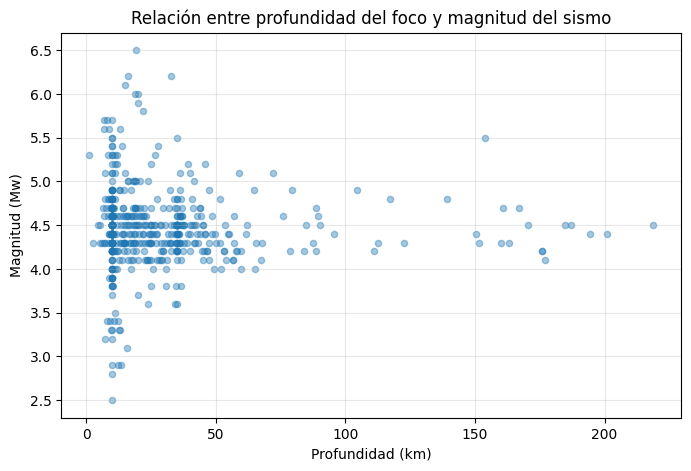

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sismos.plot(x="depth", y="mag", kind="scatter", ax=ax, color=AZUL, alpha=0.4)

ax.set_title("Relación entre profundidad del foco y magnitud del sismo")
ax.set_xlabel("Profundidad (km)")
ax.set_ylabel("Magnitud (Mw)")
ax.grid(alpha=0.3)

plt.show()

Los puntos se distribuyen de forma amplia y sin un patrón lineal evidente
entre profundidad y magnitud: hay sismos de magnitud similar tanto a poca como a
gran profundidad. Esto es esperable dado que ambos tipos de sismos, los superficiales y
los profundos, responden a procesos tectónicos distintos y no a un único mecanismo que relacione
directamente estas dos variables (Linkimer et al., 2024).

## Conclusiones

La cantidad de sismos registrados en Costa Rica entre 2015 y 2025 varía de un año a otro,
con algunos años de mayor actividad asociados a enjambres sísmicos o a secuencias de réplicas
tras un sismo principal, sin una tendencia sostenida de aumento o disminución a lo largo del
período. La distribución de magnitudes confirma que los sismos de baja magnitud son ampliamente
predominantes, mientras que los de magnitud alta ocurren con muy poca frecuencia, un patrón
consistente con la actividad sísmica observada en zonas de subducción. Finalmente, no se
observa una relación lineal clara entre la profundidad del foco y la magnitud del sismo,
lo que refleja la coexistencia en el país de sismicidad superficial, asociada a fallas
corticales, y sismicidad profunda, asociada a la placa de Cocos subducida.

Este análisis tiene limitaciones importantes.
El catálogo del USGS puede no coincidir exactamente con los conteos reportados por la
Red Sismológica Nacional (RSN) o el OVSICORI-UNA, ya que cada red tiene distintos umbrales de
detección y criterios de localización. Además, el análisis se restringe a sismos de
magnitud 2.5 o mayor, por lo que no refleja la totalidad de la sismicidad del país: las redes
nacionales localizan miles de sismos de menor magnitud cada año que no aparecen en el catálogo global del USGS.

## Referencias
Gutenberg, B., & Richter, C. F. (1944). Frequency of earthquakes in California. Bulletin of the Seismological Society of America, 34(4), 185-188. https://doi.org/10.1785/BSSA0340040185

Linkimer, L., Fallas, C., & Arroyo, I. G. (2024). Origen de los sismos sentidos en Costa Rica durante el año 2023. Revista Geológica de América Central, 70, 1-18. https://doi.org/10.15517/rgac.2024.58439

Observatorio Vulcanológico y Sismológico de Costa Rica. (2026). Sobre el OVSICORI. Universidad Nacional. https://www.ovsicori.una.ac.cr/

Red Sismológica Nacional. (2026). Boletines mensuales de sismicidad. Universidad de Costa Rica. https://www.rsn.ucr.ac.cr/

U.S. Geological Survey. (2009). M 6.1 - 10 km NNE of Sabanilla, Costa Rica: Tectonic summary. USGS Earthquake Hazards Program. https://earthquake.usgs.gov/earthquakes/eventpage/usp000gscg/executive

U.S. Geological Survey. (2026). Earthquake catalog [Conjunto de datos]. USGS Earthquake Hazards Program. https://earthquake.usgs.gov/earthquakes/search/

## Declaración de uso de inteligencia artificial
Se utilizó Claude como asistente para generar consultas específicas sobre el código de carga de datos desde
la API del USGS, la limpieza del conjunto de datos, las tablas y gráficos
Además se verifico el código para localizar posibles errores.